In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
import ruptures as rpt
from sklearn.cluster import DBSCAN, HDBSCAN
import multiprocessing
from concurrent import futures
from tqdm import tqdm

import sys

sys.path.append("../..")

from src import IOFunctions
from IPython.display import display, clear_output

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingBase

plotter = PlottingBase.PublicationPlotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SR_F = SR_Functions.SuperRes_Functions()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

# data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = "../Camera_Calibrations/Ximea_Camera"
# data_folder = r'C:\Users\jsb92\Cambridge University Dropbox\Joseph Beckwith\Chemistry\Lee\Data\Salix\Ximea_Calibration'
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

INFO:Constants:Logging to file: /home/jsb92/Documents/pyBayerSMLM/logs/Constants_20260209_111053.log
/tmp/ipykernel_3961281/3460968574.py:30: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=False)


In [2]:
dye_data_folder = '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260202_HollidayJunctions/200mMMgCl2'

In [4]:
loc_files = H_F.file_search(dye_data_folder, ".h5", "")
metadata_files = H_F.file_search(dye_data_folder, "metadata", "")
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])

In [ ]:
# two things to do
# eliminate things close to 0.33 in all channels (just initial guess!)
# look for colour CPs

In [66]:
test = pd.read_hdf(loc_files[1])

In [136]:
test2 = test[test.puncta_id == 22]

In [144]:
test2.chi_sqr[np.isclose(test2.A_B, 0.33, atol=0.01)]

2076      2.454165
2108      2.230129
2152      1.924086
2161      2.204829
2196      2.702150
2197      2.652837
2198      2.698609
2201      2.275450
2206      2.533983
2217      2.047341
2249      2.419270
2251      2.523404
2274      2.725521
2276      2.539735
2298      3.045022
2314      2.188118
2315      2.105357
2331      2.450883
2344      2.302660
2345      2.899364
2349      2.477692
2352      2.887357
2360      2.350273
2363      2.575172
2371      2.601987
2372      3.033790
2374      2.863076
2387      2.563687
136876    2.713477
136880    2.599379
136882    2.944768
136884    3.062966
136889    2.145058
136893    2.597157
136894    2.937337
136898    2.975914
136903    3.146351
136910    3.190908
136915    3.180951
136918    2.693979
136929    2.779869
136931    2.809858
136935    2.817544
136938    3.112476
136949    2.922318
136950    3.051854
Name: chi_sqr, dtype: float32

(0.0, 1.0)

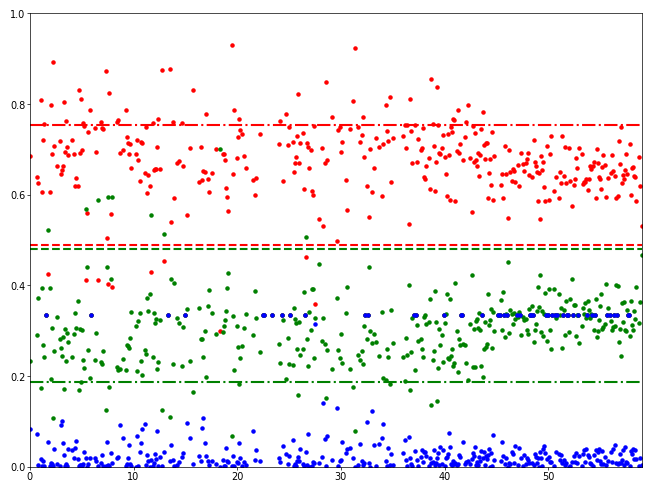

In [137]:
plt.scatter(x=test2.frame*0.1, y=test2.A_R, s=5, color='red')
plt.scatter(x=test2.frame*0.1, y=test2.A_G, s=5, color='green')
plt.scatter(x=test2.frame*0.1, y=test2.A_B, s=5, color='blue')
xmax = np.max(test2.frame*0.1)
plt.hlines(xmax=xmax, xmin=0, y=dye_pixel_efficiency_Cy3[1], color='green', ls='--')
plt.hlines(xmax=xmax, xmin=0, y=dye_pixel_efficiency_Cy3[2], color='red', ls='--')

plt.hlines(xmax=xmax, xmin=0, y=dye_pixel_efficiency_Cy5[1], color='green', ls='-.')
plt.hlines(xmax=xmax, xmin=0, y=dye_pixel_efficiency_Cy5[2], color='red', ls='-.')
plt.xlim([0, xmax])
plt.ylim([0, 1])

(0.0, 40.0)

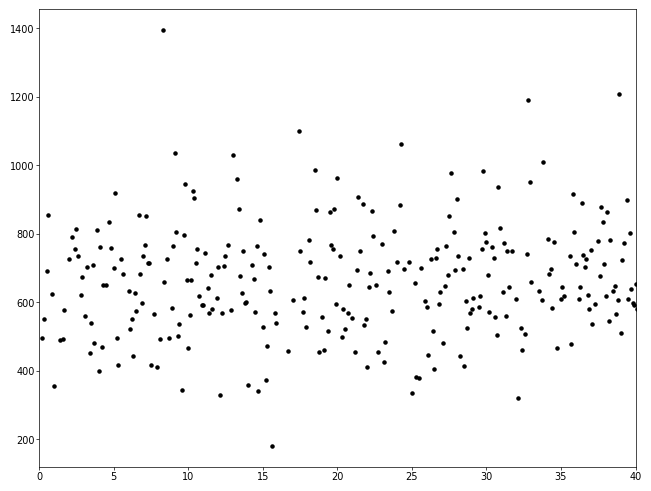

In [130]:
plt.scatter(x=test2.frame*0.1, y=test2.photons, s=5, color='black')
#plt.hlines(xmax=40, xmin=0, y=dye_pixel_efficiency_Cy3[1], color='green', ls='--')
#plt.hlines(xmax=40, xmin=0, y=dye_pixel_efficiency_Cy3[2], color='red', ls='--')

#plt.hlines(xmax=40, xmin=0, y=dye_pixel_efficiency_Cy5[1], color='green', ls='-.')
#plt.hlines(xmax=40, xmin=0, y=dye_pixel_efficiency_Cy5[2], color='red', ls='-.')
plt.xlim([0, 40])

In [87]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r488-561-t1-25x36"
dichroic_mirror_all = "semrock-di03-r405-488-561-635-t1-25x36"
shortpass_filter = "semrock-bsp01-785r"
longpass_red_filter = "semrock-blp01-635r"

longpass_filter = "semrock-blp01-568r"
filters = [dichroic_mirror]
dye = "Cy3"
average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, pixel_QYs)
)
dye_pixel_efficiency_Cy3 = dye_pixel_efficiency / np.sum(dye_pixel_efficiency)

In [88]:
dye = "Cy5"
average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, pixel_QYs)
)
dye_pixel_efficiency_Cy5 = dye_pixel_efficiency / np.sum(dye_pixel_efficiency)

In [5]:
dye_pixel_efficiency_Cy3

array([ 0.02106169,  0.38407764,  0.59486068])

In [6]:
dye_pixel_efficiency_Cy5

array([ 0.0597236 ,  0.18648028,  0.75379612])

In [111]:
def CPs_from_futures(fs):
    """
    function to return CPs from a futures object

    Args:
        fs (futures object): object

    Returns:
        frames (np.ndarray): frames
    """
    frames = {}
    results = [_.result() for _ in fs]
    for frame_vals in results:
        if isinstance(frame_vals, list):
            for frame in frame_vals:
                if np.any(np.isnan(frame)):
                    continue
                else:
                    frames[int(frame[0] / 1000)] = np.squeeze(frame)
        else:
            if np.any(np.isnan(frame_vals)):
                continue
            else:
                frames[int(frame_vals[0] / 1000)] = np.squeeze(frame_vals)
    return frames

In [112]:
def find_CPs(photoelectron_data, values):
    frames = []
    for value, i in enumerate(values):
        signal = photoelectron_data[value]
        n = len(signal)
        dim = 1
        sigma = np.nanstd(signal[-100:])
        model = "l2"  # "l2", "rbf"
        algo = rpt.Pelt(model=model, min_size=5, jump=1).fit(signal)
        my_CPs = algo.predict(pen=n * dim * sigma**2)
        if len(my_CPs) > 1:
            frames.append(np.arange(my_CPs[-2]) + (1000 * (i + 1)))
        else:
            frames.append(np.NAN)
    return frames

In [113]:
def find_CP_parallel(photoelectron_traces, n_puncta):
    n_workers = min(60, max(1, int(0.9 * multiprocessing.cpu_count())))
    n_puncta = len(n_puncta)
    n_tasks = np.min([int(n_puncta / n_workers), 100 * n_workers])
    puncta_per_task = [
        (
            int(n_puncta / n_tasks + 1)
            if _ < n_puncta % n_tasks
            else int(n_puncta / n_tasks)
        )
        for _ in range(n_tasks)
    ]
    start_indices = np.cumsum([0] + puncta_per_task[:-1])
    fs = []
    executor = futures.ProcessPoolExecutor(n_workers)
    for i, n_puncta_task in zip(start_indices, puncta_per_task):
        fs.append(
            executor.submit(
                find_CPs,
                photoelectron_traces[i : i + n_puncta_task, :],
                np.arange(i, i + n_puncta_task),
            )
        )
    with tqdm(desc="Finding CPs", total=n_tasks, unit="task") as progress_bar:
        for f in futures.as_completed(fs):
            progress_bar.update()
    return CPs_from_futures(fs)

In [ ]:
def CP_colourtraces(
    photoelectron_data,
    smoothed_data,
    weights,
    masks,
    puncta,
    photoelectron_traces,
    width,
    height,
    ROI_size=12,
):
    puncta = puncta.astype("float")
    frames = {}

    frames = find_CP_parallel(
        photoelectron_traces, np.arange(photoelectron_traces.shape[0])
    )
    masks = np.dstack([masks[x] for x in masks.keys()])
    fit_results = SR_F.fit_FRET_data(
        photoelectron_data,
        smoothed_data,
        weights,
        masks,
        puncta,
        frames,
        width,
        height,
        ROI_size,
    )
    fit_results[fit_results["chi_sqr"] > 2] = np.NAN
    return fit_results

In [ ]:
fit_results = CP_colourtraces(
    data, smoothed_data, weights, masks, puncta, photoelectron_traces, width, height
)

In [ ]:
unique_traces = np.unique(np.around(np.unique(fit_results["frame"] / 1000)))
unique_traces = unique_traces[~np.isnan(unique_traces)]

In [ ]:
for trace_val in unique_traces:
    subset = fit_results[np.around(fit_results["frame"] / 1000) == trace_val]
    fig, axs = plotter.two_column_plot(ncolumns=3, widthratio=[1, 1, 1])
    t = 100 * (subset["frame"].to_numpy() / 1000 - trace_val)
    photons = subset["A_R"] + subset["A_G"] + subset["A_B"]
    axs[0] = plotter.scatter_plot(
        axs[0], x=t, y=photons, xaxislabel="time/s", yaxislabel="photons"
    )
    # plt.plot(t, photoelectron_traces[i, :], color='black')
    ratio = subset["A_R"] / subset["A_G"]
    axs[1] = plotter.scatter_plot(
        axs[1],
        x=t,
        y=ratio,
        xaxislabel="time/s",
        yaxislabel="R/G ratio",
        facecolor="red",
    )
    xmin, xmax = axs[1].get_xlim()
    axs[1].hlines(
        y=dye_pixel_efficiency_Cy5[2] / dye_pixel_efficiency_Cy5[1],
        xmin=xmin,
        xmax=xmax,
        ls="--",
        color="darkred",
    )
    axs[1].hlines(
        y=dye_pixel_efficiency_Cy3[2] / dye_pixel_efficiency_Cy3[1],
        xmin=xmin,
        xmax=xmax,
        ls="--",
        color="orange",
    )
    axs[1].set_xlim([xmin, xmax])
    ymin, ymax = axs[1].get_ylim()
    if dye_pixel_efficiency_Cy5[2] / dye_pixel_efficiency_Cy5[1] > ymax:
        axs[1].set_ylim(
            ymin, 1.1 * (dye_pixel_efficiency_Cy5[2] / dye_pixel_efficiency_Cy5[1])
        )

    axs[2] = plotter.scatter_plot(
        axs[2],
        x=photons,
        y=ratio,
        xaxislabel="photons",
        yaxislabel="R/G ratio",
        facecolor="green",
    )
    xmin, xmax = axs[2].get_xlim()
    axs[2].hlines(
        y=dye_pixel_efficiency_Cy5[2] / dye_pixel_efficiency_Cy5[1],
        xmin=xmin,
        xmax=xmax,
        ls="--",
        color="darkred",
    )
    axs[2].hlines(
        y=dye_pixel_efficiency_Cy3[2] / dye_pixel_efficiency_Cy3[1],
        xmin=xmin,
        xmax=xmax,
        ls="--",
        color="orange",
    )
    axs[2].set_xlim([xmin, xmax])
    ymin, ymax = axs[2].get_ylim()
    if dye_pixel_efficiency_Cy5[2] / dye_pixel_efficiency_Cy5[1] > ymax:
        axs[2].set_ylim(
            ymin, 1.1 * (dye_pixel_efficiency_Cy5[2] / dye_pixel_efficiency_Cy5[1])
        )

    clear_output(wait=True)
    plt.pause(5)